# Near optimal centering

A classic optimiser returns the single point that *exactly* extremises its objective — the
maximum-ratio portfolio, the minimum-variance portfolio, and so on. That point often sits on a
knife edge: a corner solution that loads heavily on a handful of assets and shifts a lot when
the inputs wobble. `NearOptimalCentering` (NOC) trades a sliver of optimality for
stability. Instead of the extreme point, it returns the portfolio at the **analytic centre of
the near-optimal neighbourhood** — the region of solutions that are *almost* as good as the
optimum. The neighbourhood is parametrised by binning the efficient frontier (`bins`).

We met NOC briefly as a frontier/surface engine in the efficient-frontier and Pareto-surface
examples; here we focus on the behaviour that makes it its own optimiser: how its centred
solution differs from the extreme point of the same objective.

> **When to reach for this**
>
> Reach for NOC when you like a `MeanRisk` objective but distrust its corner
> solutions — when you want the spirit of "maximum risk-adjusted return" without betting the
> book on two assets, or a more stable allocation that survives small changes in the prior.
> Use `UnconstrainedNearOptimalCentering` for the plain centred portfolio, and
> `ConstrainedNearOptimalCentering` when the centred solution must also satisfy the
> problem's external constraints (at the cost of a harder solve). If you genuinely want the
> extreme point, use `MeanRisk` directly.

In [1]:
using PortfolioOptimisers, PrettyTables

resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data

We use the same S&P 500 slice as the other optimiser examples.

In [2]:
using CSV, TimeSeries, DataFrames

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)

ReturnsResult
    nx ┼ 20-element Vector{String}
     X ┼ 252×20 Matrix{Float64}
    nf ┼ nothing
     F ┼ nothing
    nb ┼ nothing
     B ┼ nothing
    ts ┼ 252-element Vector{Date}
    iv ┼ nothing
  ivpa ┴ nothing


## 2. Prior and solvers

NOC solves a harder problem than a plain `MeanRisk` (it bins the frontier and centres within a
neighbourhood), so a single solver configuration can fail to converge. We therefore pass a
*vector* of solvers with decreasing `max_step_fraction`; the optimiser falls back through them
until one succeeds. We also use the SOC-based `StandardDeviation` risk measure — see
the findings note on why a plain quadratic `Variance` is not a good fit for NOC.

In [3]:
using Clarabel

slv = [Solver(; name = Symbol("clarabel$i"), solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => f),
              check_sol = (; allow_local = true, allow_almost = true))
       for (i, f) in enumerate((0.99, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7))]

pr = prior(EmpiricalPrior(), rd)
rf = 4.2 / 100 / 252
opt = JuMPOptimiser(; pe = pr, slv = slv)

JuMPOptimiser
       pe ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
      slv ┼ 7-element Vector{Solver}
          │ Solver ⋯
          │ Solver ⋯
          │ Solver ⋯
          │ Solver ⋯
          │ Solver ⋯
          │ Solver ⋯
          │ Solver ⋯
       wb ┼ WeightBounds
          │   lb ┼ Float64: 0.0
          │   ub ┴ Float64: 1.0
      bgt ┼ Float64: 1.0
     sbgt ┼ nothing
       lt ┼ nothing
       st ┼ nothing
     lcse ┼ nothing
      cte ┼ nothing
   gcarde ┼ nothing
  sgcarde ┼ nothing
     smtx ┼ nothing
    sgmtx ┼ nothing
      slt ┼ nothing
      sst ┼ nothing
     sglt 

## 3. The reference: a `MeanRisk` corner solution

First the plain maximum risk-adjusted return portfolio. This is the extreme point NOC will
centre around.

In [4]:
res_mr = optimise(MeanRisk(; r = StandardDeviation(), obj = MaximumRatio(; rf = rf),
                           opt = opt))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        oe ┼ DataType: DataType
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePreci

## 4. Unconstrained near optimal centering

Now the same objective through NOC. `UnconstrainedNearOptimalCentering` does not impose
the problem's external constraints on the centred solution, which keeps the solve tractable.

In [5]:
res_noc_u = optimise(NearOptimalCentering(; r = StandardDeviation(),
                                          obj = MaximumRatio(; rf = rf), opt = opt,
                                          alg = UnconstrainedNearOptimalCentering()))

NearOptimalCenteringResult
             jr ┼ JuMPOptimisationResult
                │        oe ┼ DataType: DataType
                │        pa ┼ ProcessedJuMPOptimiserAttributes
                │           │        pr ┼ LowOrderPrior
                │           │           │         X ┼ 252×20 Matrix{Float64}
                │           │           │        mu ┼ 20-element Vector{Float64}
                │           │           │     sigma ┼ 20×20 Matrix{Float64}
                │           │           │      chol ┼ nothing
                │           │           │         w ┼ nothing
                │           │           │       ens ┼ nothing
                │           │           │       kld ┼ nothing
                │           │           │        ow ┼ nothing
                │           │           │        rr ┼ nothing
                │           │           │      f_mu ┼ nothing
                │           │           │   f_sigma ┼ nothing
                │           │     

## 5. Constrained near optimal centering

`ConstrainedNearOptimalCentering` additionally requires the centred portfolio to
satisfy the external constraints. It is a harder solve (hence the solver fallback vector), but
keeps the result feasible with respect to whatever bounds or budgets you have imposed.

In [6]:
res_noc_c = optimise(NearOptimalCentering(; r = StandardDeviation(),
                                          obj = MaximumRatio(; rf = rf), opt = opt,
                                          alg = ConstrainedNearOptimalCentering()))

NearOptimalCenteringResult
             jr ┼ JuMPOptimisationResult
                │        oe ┼ DataType: DataType
                │        pa ┼ ProcessedJuMPOptimiserAttributes
                │           │        pr ┼ LowOrderPrior
                │           │           │         X ┼ 252×20 Matrix{Float64}
                │           │           │        mu ┼ 20-element Vector{Float64}
                │           │           │     sigma ┼ 20×20 Matrix{Float64}
                │           │           │      chol ┼ nothing
                │           │           │         w ┼ nothing
                │           │           │       ens ┼ nothing
                │           │           │       kld ┼ nothing
                │           │           │        ow ┼ nothing
                │           │           │        rr ┼ nothing
                │           │           │      f_mu ┼ nothing
                │           │           │   f_sigma ┼ nothing
                │           │     

## 6. Comparing the allocations

The contrast is the whole point. The extreme maximum-ratio portfolio piles into a couple of
assets; both NOC variants spread the same objective across many more names by sitting at the
centre of the near-optimal region rather than at its corner.

In [7]:
pretty_table(DataFrame(; :assets => rd.nx, Symbol("MaxRatio (extreme)") => res_mr.w,
                       Symbol("NOC unconstrained") => res_noc_u.w,
                       Symbol("NOC constrained") => res_noc_c.w); formatters = [resfmt])

┌────────┬────────────────────┬───────────────────┬─────────────────┐
│ assets │ MaxRatio (extreme) │ NOC unconstrained │ NOC constrained │
│ String │            Float64 │           Float64 │         Float64 │
├────────┼────────────────────┼───────────────────┼─────────────────┤
│   AAPL │              0.0 % │           0.463 % │         0.463 % │
│    AMD │              0.0 % │           0.281 % │         0.281 % │
│    BAC │              0.0 % │           0.505 % │         0.505 % │
│    BBY │              0.0 % │           0.684 % │         0.684 % │
│    CVX │              0.0 % │           2.785 % │         2.785 % │
│     GE │              0.0 % │           0.622 % │         0.622 % │
│     HD │              0.0 % │           0.606 % │         0.606 % │
│    JNJ │              0.0 % │           1.206 % │         1.206 % │
│    JPM │              0.0 % │           0.644 % │         0.644 % │
│     KO │              0.0 % │           1.377 % │         1.377 % │
│    LLY │          

A quick numeric summary of the diversification difference: the largest single weight and the
number of materially-held assets.

In [8]:
summarise(w) = (round(maximum(w) * 100; digits = 2), count(>(1e-4), w))
pretty_table(DataFrame(;
                       :portfolio =>
                           ["MaxRatio (extreme)", "NOC unconstrained", "NOC constrained"],
                       Symbol("max weight %") =>
                           [summarise(res_mr.w)[1], summarise(res_noc_u.w)[1],
                            summarise(res_noc_c.w)[1]],
                       Symbol("assets held") =>
                           [summarise(res_mr.w)[2], summarise(res_noc_u.w)[2],
                            summarise(res_noc_c.w)[2]]))

┌────────────────────┬──────────────┬─────────────┐
│          portfolio │ max weight % │ assets held │
│             String │      Float64 │       Int64 │
├────────────────────┼──────────────┼─────────────┤
│ MaxRatio (extreme) │        66.04 │           2 │
│  NOC unconstrained │         42.4 │          20 │
│    NOC constrained │         42.4 │          20 │
└────────────────────┴──────────────┴─────────────┘


## 7. Visualising the compositions

The stacked-bar composition shows the corner solution collapsing onto a few assets while NOC
fans the allocation out.

Composition: extreme MaxRatio vs the two NOC variants.

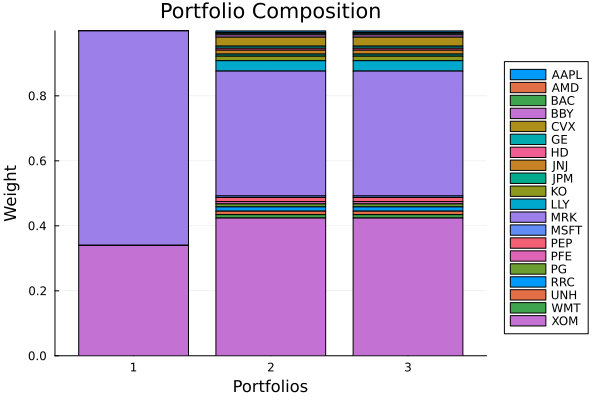

In [9]:
using StatsPlots, GraphRecipes
plot_stacked_bar_composition([res_mr, res_noc_u, res_noc_c], rd)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*